In [1]:
import pandas as pd

# 1️⃣ Load dataset
df = pd.read_excel("ALL_with_features.xlsx")

# 2️⃣ Clean column names
df.columns = df.columns.str.strip()              # remove leading/trailing spaces
df.columns = df.columns.str.replace(" ", "_")   # replace spaces with underscores

# 3️⃣ Fill missing DoK_Level values with median
df['DoK_Level'] = df['DoK_Level'].fillna(df['DoK_Level'].median())

# 4️⃣ Ensure numeric columns are correct type
numeric_cols = ['Lexical_Diversity', 'Avg_Sentence_Length', 'Readability', 'DoK_Level']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 5️⃣ Save changes permanently by overwriting the same file
df.to_excel("ALL_with_features.xlsx", index=False)

print("Dataset cleaned and saved permanently in the same file.")
print(df.head())

Dataset cleaned and saved permanently in the same file.
     Item_ID                                               Item  \
0  HiBloom_1  Anne had a password in her phone represented b...   
1  HiBloom_2  Musoke had two wives one in Kanginima village ...   
2  HiBloom_3  On the last Sunday of the holiday Your uncle d...   
3  HiBloom_4  During their baking lesson, the students were ...   
4  HiBloom_5  A certain member of your family re-wrote each ...   

               Construct Bloom_Level  \
0                Numbers    Analyse    
1   Data and Probability    Evaluate   
2                Numbers      Create   
3   Patterns and Algebra    Analyse    
4  Geometry and Measures    Evaluate   

                                  Bloom_Action_Verbs  DoK_Level  \
0  Analyze, Appraise, Break down, Categorize, Cla...   3.499264   
1  Appraise; Argue; Assess; Check; Conclude; Conf...   3.000000   
2  Adapt; Assemble; Combine; Compile; Compose; Co...   4.000000   
3  Analyze, Appraise, Break down

In [2]:
%pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 3.4 MB/s eta 0:00:08
    --------------------------------------- 0.5/24.4 MB 3.4 MB/s eta 0:00:08
   -- ------------------------------------- 1.3/24.4 MB 1.6 MB/s eta 0:00:15
   --- ------------------------------------ 1.8/24.4 MB 2.0 MB/s eta 0:00:12
   --- ------------------------------------ 2.4/24.4 MB 1.9 MB/s eta 0:00:12
   ---- ----------------------------------- 2.9/24.4 MB 2.1 MB/s eta 0:00:11
   ----- ---------------------------------- 3.1/24.4 MB 2.2 MB/s eta 0:00:10
   ----- ---------------------------------- 3.1/24.4 MB 2.2 MB/s eta 0:00:10
   ------ --------------------------------- 3.7/24.4 MB 1.8 MB/s eta 0:00:12
   ------ --------------------------------- 4.2/24.4 MB 1.8 MB/s eta 0:00:12
   ------- -------------------------------- 4.5/24.4 MB 1.8 MB/s eta 0:00:11
   ------- --

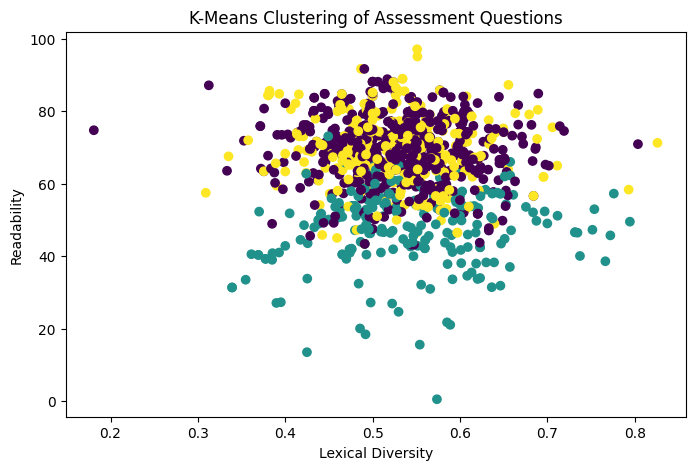

 K-Means Evaluation 
Silhouette Score (higher is better): 0.239
Davies-Bouldin Index (lower is better): 1.379
Calinski-Harabasz Index (higher is better): 303.726

LDA Evaluation 
LDA Coherence Score (higher is better): 0.277


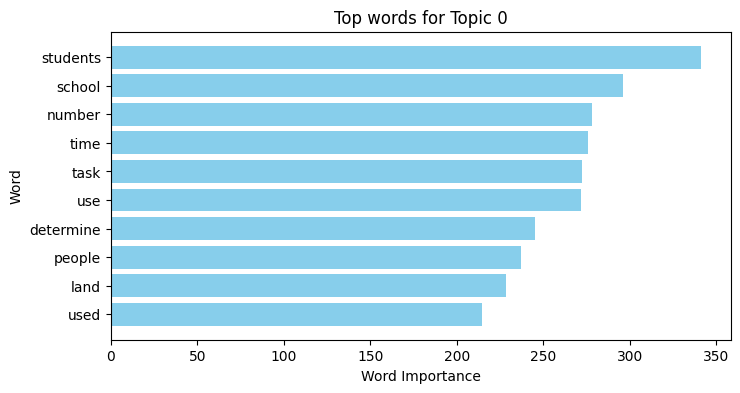

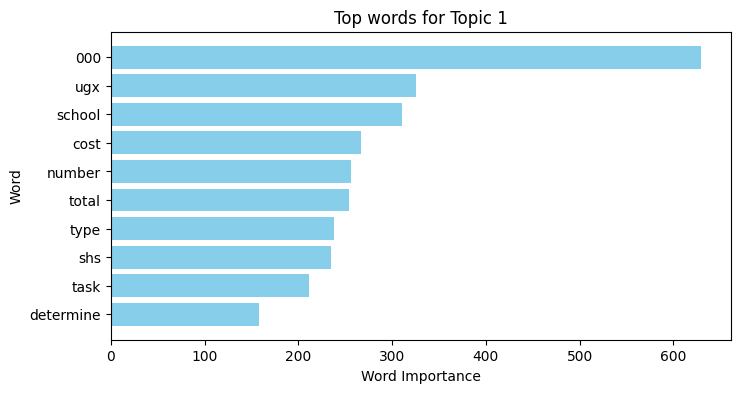

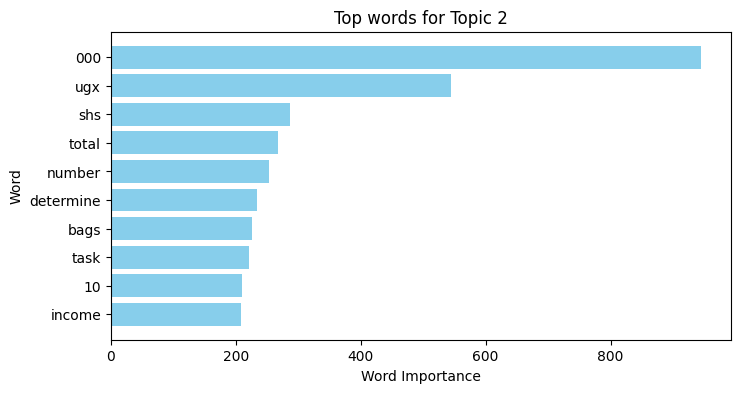

 Dataset updated with Cluster and Topic columns and saved.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
import numpy as np


# Load dataset
df = pd.read_excel("ALL_with_features.xlsx")

# Prepare numeric features for K-Means
features = df[['Lexical_Diversity','Avg_Sentence_Length','Readability','DoK_Level']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

#Train K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize K-Means clusters
plt.figure(figsize=(8,5))
plt.scatter(df['Lexical_Diversity'], df['Readability'], c=df['Cluster'], cmap='viridis')
plt.title("K-Means Clustering of Assessment Questions")
plt.xlabel("Lexical Diversity")
plt.ylabel("Readability")
plt.show()

# Evaluate K-Means
sil_score = silhouette_score(X_scaled, df['Cluster'])
db_score = davies_bouldin_score(X_scaled, df['Cluster'])
ch_score = calinski_harabasz_score(X_scaled, df['Cluster'])

print(" K-Means Evaluation ")
print(f"Silhouette Score (higher is better): {sil_score:.3f}")
print(f"Davies-Bouldin Index (lower is better): {db_score:.3f}")
print(f"Calinski-Harabasz Index (higher is better): {ch_score:.3f}")

#  Prepare text for LDA
vectorizer = CountVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(df['Item'])

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X_text)

# Assign topic to each question
topic_results = lda.transform(X_text)
df['Topic'] = topic_results.argmax(axis=1)

#  Evaluate LDA with Coherence
texts = [doc.split() for doc in df['Item']]
id2word = corpora.Dictionary(texts)
corpus = [id2word.doc2bow(text) for text in texts]

lda_model = gensim.models.LdaModel(corpus=corpus,
                                   id2word=id2word,
                                   num_topics=3,
                                   random_state=42,
                                   passes=10)

coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()

print("\nLDA Evaluation ")
print(f"LDA Coherence Score (higher is better): {coherence_lda:.3f}")


#  Deployment Justification
if sil_score > 0.5 and coherence_lda < 0.4:
    print("K-Means is chosen for deployment: clusters are well-separated and compact.")
elif coherence_lda > 0.4 and sil_score < 0.5:
    print("LDA is chosen for deployment: topics are meaningful and interpretable.")
elif sil_score > 0.5 and coherence_lda > 0.4:
    print("Both models are viable. Decision depends on app goal:\n"
          "- Numeric grouping → K-Means\n- Topic extraction → LDA")
    
# Visualize LDA top words per topic
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:]
    top_words = [words[i] for i in top_words_idx]
    top_values = topic[top_words_idx]

    plt.figure(figsize=(8,4))
    plt.barh(top_words, top_values, color='skyblue')
    plt.title(f"Top words for Topic {topic_idx}")
    plt.xlabel("Word Importance")
    plt.ylabel("Word")
    plt.show()

# Save updated dataset
df.to_excel("ALL_with_features.xlsx", index=False)
print(" Dataset updated with Cluster and Topic columns and saved.")

In [ ]:
import joblib
# Save K-Means model
joblib.dump(kmeans, "kmeans_model.pkl")
# Save LDA model
joblib.dump(lda, "lda_model.pkl")

print("K-Means and LDA models saved as .pkl files")

K-Means and LDA models saved as .pkl files


In [12]:
%pip install dataframe-image

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.7 MB 493.7 kB/s eta 0:00:13
   ---- ----------------------------------- 0.8/6.7 MB 633.2 kB/s eta 0:00:10
   ---- ----------------------------------- 0.8/6.7 MB 633.2 kB/s eta 0:00:10
   ---- ----------------------------------- 0.8/6.7 MB 633.2 kB/s eta 0:00:10
   ---- ----------------------------------- 0.8/6.7 MB 633.2 kB/s eta 0:00:10
   ------ --------------------------------- 1.0/6.7 MB 508.4 kB/s eta 0:00:12
   ------ --------------------------------- 1.0/6.7 MB 508.4 kB/s eta 0:00:12
   ------ --------------------------------- 1.

In [1]:
import pandas as pd
import dataframe_image as dfi  

#Prepare topic data
topics = {
    0: ['used', 'land', 'people', 'determine', 'use', 'task', 'time', 'number', 'school', 'students'],
    1: ['determine', 'task', 'shs', 'type', 'total', 'number', 'cost', 'school', 'ugx', '000'],
    2: ['income', '10', 'task', 'bags', 'determine', 'number', 'total', 'shs', 'ugx', '000']
}

example_questions = {
    0: "Musoke had two wives one in Kanginima village …",
    1: "Anne had a password in her phone …",
    2: "During their baking lesson …"
}

# Create DataFrame
topic_df = pd.DataFrame({
    "Topic": list(topics.keys()),
    "Top Words": [", ".join(words) for words in topics.values()],
    "Example Question": [example_questions[i] for i in topics.keys()]
})

# Export as high-quality image using Matplotlib ---
dfi.export(topic_df, "lda_topics_table.png", table_conversion="matplotlib")
print(" LDA topic table image saved as 'lda_topics_table.png'")

 LDA topic table image saved as 'lda_topics_table.png'


In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import pickle

#  Load your original dataset
df = pd.read_excel("ALL_with_features.xlsx")  # or CSV if that's what you used

#  Recreate vectorizer
vectorizer = CountVectorizer(stop_words='english')
X_text = vectorizer.fit_transform(df['Item'])

#  Save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
print( "Vectorizer saved")

Vectorizer saved
